
## NIO and cost






## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')

(28, 'o_coke_rt')



In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime
## !pip install pandas
## !pip install scikit-learn
## !pip install matplotlib
## !pip install seaborn
## !pip install mlxtend
## ! pip install skl2onnx



In [2]:


import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)

import os, json, time, uuid


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [3]:


import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt




/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/onnx_ops.py:159: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  tys = obj.typeStr or ''
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/automation.py:154: UserWarning: OpSchema.FormalParameter.isHomogeneous is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.is_homogeneous instead.
  if getattr(obj, 'isHomogeneous', False):
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/jinja2/environment.py:485: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  return getattr(obj, attribute)


In [4]:

import PDFshapingUtils as PDF_tk


In [5]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()


In [6]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [7]:

## Ty suggested fix where 0 needs to be 300

PDFshapingOBJ.CFD_raw_data["i_h2_temp"] = PDFshapingOBJ.CFD_raw_data["i_h2_temp"].replace(0, 300)


In [8]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,300,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


In [9]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

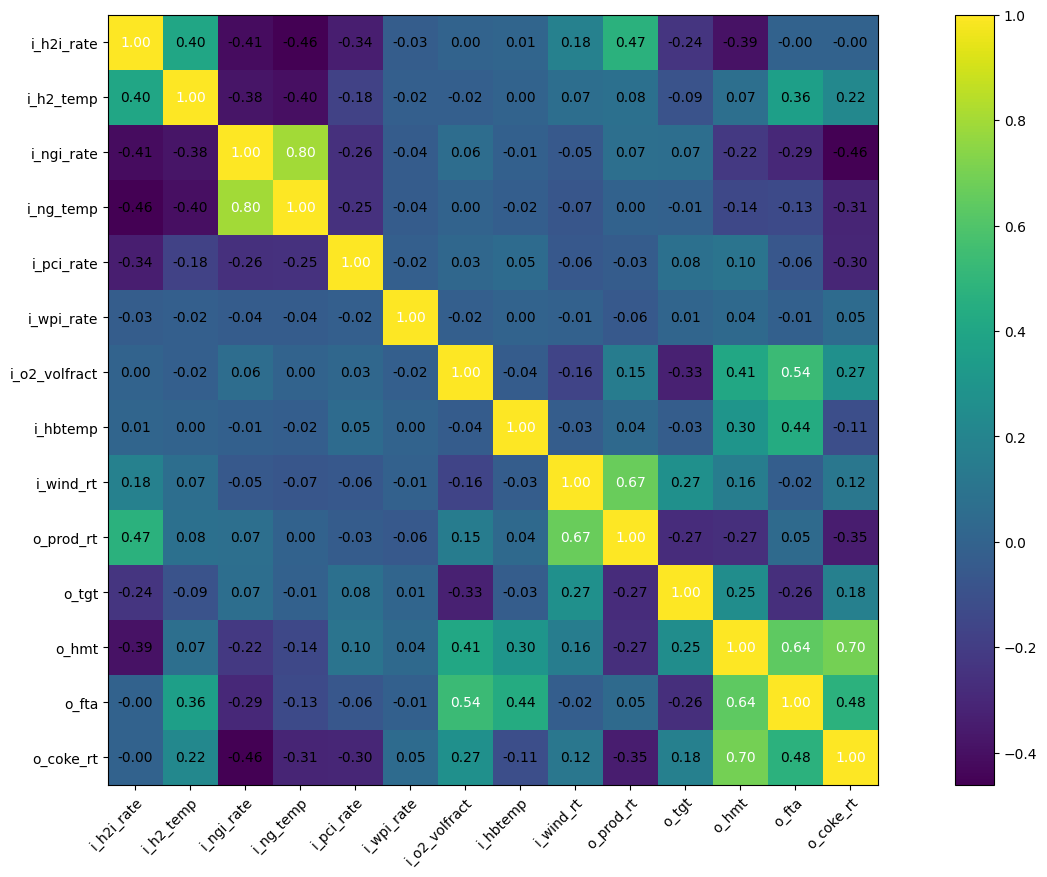

In [10]:


PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','o_prod_rt', 'o_tgt', 'o_hmt','o_fta', 'o_coke_rt']



PDFshapingOBJ.print_correlation_coefficients()


In [11]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)


In [12]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [  2, 3, 5, 6, 8, 9, 10   ] , 
                   outputs= [ 27, 29, 39, 40, 28 ]   
)


## inputs = [ 2, 3, 5, 6, 8, 9, 10  ]          ## the full 7



7
5


In [13]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 7)
(4999, 5)


In [14]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [15]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [16]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [17]:

'''


from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 4 components
pca = PCA(n_components=4)

# Fit on training data and transform both train and test
X_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)
X_test_pca  = pca.transform(PDFshapingOBJ.X_test)

# Replace the original inputs with PCA-reduced versions
PDFshapingOBJ.X_train = X_train_pca
PDFshapingOBJ.X_test  = X_test_pca


'''


'\n\n\nfrom sklearn.decomposition import PCA\n\n# Instantiate PCA to reduce to 4 components\npca = PCA(n_components=4)\n\n# Fit on training data and transform both train and test\nX_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)\nX_test_pca  = pca.transform(PDFshapingOBJ.X_test)\n\n# Replace the original inputs with PCA-reduced versions\nPDFshapingOBJ.X_train = X_train_pca\nPDFshapingOBJ.X_test  = X_test_pca\n\n\n'

In [18]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [19]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [20]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [21]:


PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## Model Forward ( 7x4 )


In [22]:

n_inputs  = 7     ## 7
n_outputs = 5




#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO_Forward(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations,  device='cuda'):
        super().__init__()
        self.device = device
        
        ## self.x_means      = x_means
        ## self.x_deviations = x_deviations
        ## self.y_means      = y_means
        ## self.y_deviations = y_deviations
        
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)
        
        
        
        ## F1
        self.f1_linear1 = nn.Linear(n_inputs, n_outputs)       
        
        ## F2
        self.f2_linear1 = nn.Linear(n_inputs, 10)
        self.f2_act1    = nn.Tanh()   ## nn.Sigmoid()    ## Tanh()    nn.ReLU()                 
        self.f2_linear2 = nn.Linear(10, n_outputs)       
        self.f2_dropout = nn.Dropout(0.25)
        
        # Move model to device
        self.to(self.device)
        
        
    ## perform inference
    def forward(self, x):
        x = x.to(self.device)
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        ##   y_descaled = torch.clamp(  y_descaled, min=0.0  )
        
        return y_descaled, y_scaled
    




In [23]:

n_inputs  = 7    ## 7
n_outputs = 5





    
class ResidualNet_Forward(nn.Module):
    def __init__(self, x_means, x_deviations, y_means, y_deviations, dropout_rate=0.1, device='cuda'):
        
        super().__init__()
        self.device = device
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)

     
        self.fc1  = nn.Linear(n_inputs, 64)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(64, n_outputs)

        # If input_dim ≠ 64, project for residual addition
        self.input_proj = nn.Linear(n_inputs, 64) if n_inputs != 64 else nn.Identity()
        
        # Move model to device
        self.to(self.device)
        

    def forward(self, x):
        x  = x.to(self.device)
        x  = (x - self.x_means) / self.x_deviations
        x0 = self.input_proj(x)
        x1 = self.dropout1(self.act1(self.fc1(x)))
        x2 = self.dropout2(self.act2(self.fc2(x1)))
        x_res = x2 + x0
        y_scaled = self.fc3(x_res)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

    


In [24]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## model_Forward     = F1plusF2_SIO_Forward(

model_Forward     =     F1plusF2_SIO_Forward(
                         PDFshapingOBJ.x_means, 
                         PDFshapingOBJ.x_deviations, 
                         PDFshapingOBJ.y_means, 
                         PDFshapingOBJ.y_deviations,
                         device=device  # pass device into the model
    
)

optimizer = optim.Adam(model_Forward.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()



In [25]:

model_Forward.train()

for epoch in range(1000):
    for xb, yb in PDFshapingOBJ.train_dl:
        
        xb = xb.to(model_Forward.device)
        yb = yb.to(model_Forward.device)
        
        optimizer.zero_grad()
        pred_descaled, pred_scaled = model_Forward(xb)
        
        loss = loss_fn(pred_scaled, yb)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(epoch, ".....", loss.item() ) 
    



0 ..... 0.9661299586296082
100 ..... 0.28241586685180664
200 ..... 0.1752486526966095
300 ..... 0.38325580954551697
400 ..... 0.303151398897171
500 ..... 0.14155131578445435
600 ..... 0.24202688038349152
700 ..... 0.3698263168334961
800 ..... 0.17442750930786133
900 ..... 0.38142824172973633


In [26]:

print("=== SANITY CHECK: SCALING ===")
print("y_means:", PDFshapingOBJ.y_means)
print("y_deviations:", PDFshapingOBJ.y_deviations)

print("===============================================")

print("x_means:", PDFshapingOBJ.x_means)
print("x_deviations:", PDFshapingOBJ.x_deviations)


=== SANITY CHECK: SCALING ===
y_means: tensor([[  97.6199, 1292.1968, 8425.1348, 2302.7781,  417.0729]])
y_deviations: tensor([[  50.3613,  524.1182, 1515.6217,  208.5577,   50.0614]])
x_means: tensor([[  12.3331,   18.8122,   41.5491,   25.5856,  413.7284, 1435.4729,
          198.2996]])
x_deviations: tensor([[ 15.1691,  45.4249,  46.6849,   3.3155, 270.3714, 158.8860,  26.6359]])


In [27]:

print(PDFshapingOBJ.y_means -  PDFshapingOBJ.y_deviations)
print(PDFshapingOBJ.y_means +  PDFshapingOBJ.y_deviations)


tensor([[  47.2586,  768.0786, 6909.5132, 2094.2205,  367.0115]])
tensor([[ 147.9812, 1816.3149, 9940.7568, 2511.3357,  467.1343]])


In [28]:

print(PDFshapingOBJ.x_means -  PDFshapingOBJ.x_deviations)
print(PDFshapingOBJ.x_means +  PDFshapingOBJ.x_deviations)


tensor([[  -2.8360,  -26.6127,   -5.1357,   22.2701,  143.3571, 1276.5869,
          171.6637]])
tensor([[  27.5022,   64.2371,   88.2340,   28.9012,  684.0998, 1594.3589,
          224.9354]])


In [29]:

import numpy as np
from numpy.linalg import norm

# --- distance function ---
def euclid(a, b):
    return norm(a - b)



## Now add Costs


In [30]:

def regularize_z(z, strength=1e-3):
    
    return strength * torch.sum(z**2)


In [31]:

clamp_min = torch.tensor([[   0,   0,   0,    21,   300,   1200, 150 ]])     ## from Ty
clamp_max = torch.tensor([[ 300, 300, 300,    90,  3000,   1500, 220 ]])



get_x_from_z = lambda z: clamp_min + (clamp_max - clamp_min) * torch.sigmoid(z)


In [32]:

def wrapped_model(x):
    y_descaled, _ = model_Forward(x)
    return y_descaled  


In [33]:

price_real = np.array([4.0, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0])

price_real = torch.tensor(price_real, dtype=torch.float32)


model_Forward.eval()


for p in model_Forward.parameters():
    p.requires_grad = False



In [34]:

lambda_cost = 0.1        ## 0.01    ## 0.001   ## this gave 86% percent of cases improvement
## lambda_cost = 0.0

dist_method_A = []
dist_method_B = []
cost_diffs    = [] 
cost_diff     = 0

actual_pred_cost = []
actual_real_cost = []

percent_diffs = []
percent_diff  = 0 

learning_rate = 0.01        ## 0.001      ## 1e-5


In [35]:



for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    target_y  = (target_y  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
    
    ## x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point
    ## x_temp = x_starting_point.clone().detach().requires_grad_(True)
    ## z_init = torch.rand((1,7))*0.4 + 0.3
    
    z_init = torch.rand((1,7))*0.2 + 0.3
    z = torch.nn.Parameter(torch.logit(z_init))    ## this requires grad 
          

    ## x_temp = torch.randn_like(x_starting_point).requires_grad_(True)

    optimizer = torch.optim.Adam([z], lr=learning_rate)
    
   
    
    for j in range(2000):             ## 1000
        
        optimizer.zero_grad()
        
        x_temp = get_x_from_z(  z  )
        
        _, current_y = model_Forward(x_temp)
        
        
        loss_z_reg = regularize_z(z, strength=1e-3)
        loss_main  = torch.mean((current_y - target_y)**2)
        ## loss_cost  = lambda_cost * torch.dot(price_real, x_temp)
        loss_cost  = lambda_cost * (x_temp @ price_real)
        loss       = loss_main + loss_cost + loss_z_reg
        
        loss.backward()
        optimizer.step()
        
        
    
        #######################
        
     
        x_temp_pred_np   = x_temp.detach().numpy()
        ## cost_pred        = np.dot(   price_real, x_temp_pred_np)
        cost_pred        = torch.dot(price_real, x_temp.squeeze()).item()
        
        x_real_np        = x_real.detach().numpy() 
        cost_real        = np.dot(price_real, x_real_np)
       
        if j % 400 == 0:           ## 20
            print(f"iteration {j} cost: {cost_pred}...H2, PCI, NGI:", x_temp_pred_np[:,:3] )
            print("real cost       :", cost_real)
            print( "total loss", loss      )
            print( "loss_main",  loss_main )
            print( "loss_cost",  loss_cost )
        
   
        cost_diff = cost_pred - cost_real
        if cost_real > 0:                         ## handle nans
            percent_diff = cost_diff / cost_real
            percent_diffs.append(percent_diff)
        
          
    cost_diffs.append(    cost_diff  )
    
    actual_pred_cost.append(  cost_pred  )
    actual_real_cost.append(  cost_real  )
      

    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    
    
    print("...")
    print("...")
    print("...")
    print( the_cols )
    print( "pred" )
    print( x_temp_pred_np )
    print( "real" )
    print( x_real_np )
    print("...")
    
    
    print( "o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt" )
    print( "y pred" )
    print( wrapped_model(torch.from_numpy(x_temp_pred_np))   )
    print( "y real" )
    print( wrapped_model(torch.from_numpy(x_real_np))   )
    
    dist_method_A.append( euclid(x_temp_pred_np, x_real_np) )
    dist_method_B.append( euclid(
                    wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().numpy() , 
                    wrapped_model(torch.from_numpy(x_real_np)).detach().numpy()
    ))
    
    print(i)
    print('********************************')




iteration 0 cost: 584.1748657226562...H2, PCI, NGI: [[100.088394 116.51058  134.62146 ]]
real cost       : 60.0
total loss tensor([77.1255], grad_fn=<AddBackward0>)
loss_main tensor(18.7061, grad_fn=<MeanBackward0>)
loss_cost tensor([58.4175], grad_fn=<MulBackward0>)
iteration 400 cost: 82.36186218261719...H2, PCI, NGI: [[13.480691 16.270178 24.337837]]
real cost       : 60.0
total loss tensor([9.9344], grad_fn=<AddBackward0>)
loss_main tensor(1.6612, grad_fn=<MeanBackward0>)
loss_cost tensor([8.2362], grad_fn=<MulBackward0>)
iteration 800 cost: 30.818225860595703...H2, PCI, NGI: [[ 4.921256   6.0495424 10.167321 ]]
real cost       : 60.0
total loss tensor([4.0676], grad_fn=<AddBackward0>)
loss_main tensor(0.9123, grad_fn=<MeanBackward0>)
loss_cost tensor([3.0818], grad_fn=<MulBackward0>)
iteration 1200 cost: 17.110488891601562...H2, PCI, NGI: [[2.6974356 3.273771  6.0939517]]
real cost       : 60.0
total loss tensor([2.7635], grad_fn=<AddBackward0>)
loss_main tensor(0.9535, grad_fn=<M

iteration 1600 cost: 15.345629692077637...H2, PCI, NGI: [[2.6259253 2.7979798 4.087896 ]]
real cost       : 80.0
total loss tensor([2.8658], grad_fn=<AddBackward0>)
loss_main tensor(1.2424, grad_fn=<MeanBackward0>)
loss_cost tensor([1.5346], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   1.925597     1.9908462    2.9876642   22.87322   1141.5571
  1215.2858     154.24513  ]]
real
[  10.    0.   80.   30.  300. 1200.  160.]
...
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
y pred
tensor([[  99.8616, 1194.6486, 5164.9985, 2342.9270,  467.0255]])
y real
tensor([[  53.0447,  847.7914, 7824.2388, 2216.1938,  408.7709]])
5
********************************
iteration 0 cost: 576.861572265625...H2, PCI, NGI: [[ 99.098434 124.93161  111.07254 ]]
real cost       : 40.0
total loss tensor([73.2491], grad_fn=<AddBackward0>)
loss_main tensor(15.5618, grad_fn=<MeanBackward0>)
loss_cost tensor([57.6862], grad_fn=<Mu

iteration 400 cost: 69.14119720458984...H2, PCI, NGI: [[11.783486 12.357153 19.300198]]
real cost       : 75.0
total loss tensor([8.8429], grad_fn=<AddBackward0>)
loss_main tensor(1.8829, grad_fn=<MeanBackward0>)
loss_cost tensor([6.9141], grad_fn=<MulBackward0>)
iteration 800 cost: 31.134458541870117...H2, PCI, NGI: [[ 5.168196  5.046715 10.829919]]
real cost       : 75.0
total loss tensor([5.9105], grad_fn=<AddBackward0>)
loss_main tensor(2.7282, grad_fn=<MeanBackward0>)
loss_cost tensor([3.1134], grad_fn=<MulBackward0>)
iteration 1200 cost: 19.146825790405273...H2, PCI, NGI: [[3.214488 3.102922 6.371904]]
real cost       : 75.0
total loss tensor([5.1964], grad_fn=<AddBackward0>)
loss_main tensor(3.1962, grad_fn=<MeanBackward0>)
loss_cost tensor([1.9147], grad_fn=<MulBackward0>)
iteration 1600 cost: 13.973711967468262...H2, PCI, NGI: [[2.3788347 2.170911  4.574924 ]]
real cost       : 75.0
total loss tensor([4.9990], grad_fn=<AddBackward0>)
loss_main tensor(3.5037, grad_fn=<MeanBackw

...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   1.846076     1.7941415    3.4259925   22.064526   368.7193
  1307.5386     197.27682  ]]
real
[  30.    0.   60.   29.  300. 1480.  195.]
...
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
y pred
tensor([[ 124.9027, 1515.8948, 6639.3691, 2261.6140,  477.0344]])
y real
tensor([[  68.0621,  992.9310, 9804.7031, 2297.3638,  393.0801]])
14
********************************
iteration 0 cost: 688.0839233398438...H2, PCI, NGI: [[134.28534 105.63816  90.60874]]
real cost       : 90.0
total loss tensor([77.6460], grad_fn=<AddBackward0>)
loss_main tensor(8.8360, grad_fn=<MeanBackward0>)
loss_cost tensor([68.8084], grad_fn=<MulBackward0>)
iteration 400 cost: 103.60926818847656...H2, PCI, NGI: [[19.506147 15.878751 19.411844]]
real cost       : 90.0
total loss tensor([11.5295], grad_fn=<AddBackward0>)
loss_main tensor(1.1200, grad_fn=<MeanBackward0>)
loss_cost tensor([10.3609], grad_fn=<Mul

iteration 800 cost: 35.5048942565918...H2, PCI, NGI: [[6.3215766 5.8363037 8.764569 ]]
real cost       : 40.0
total loss tensor([3.7373], grad_fn=<AddBackward0>)
loss_main tensor(0.1276, grad_fn=<MeanBackward0>)
loss_cost tensor([3.5505], grad_fn=<MulBackward0>)
iteration 1200 cost: 18.902725219726562...H2, PCI, NGI: [[3.342271 3.090748 4.885786]]
real cost       : 40.0
total loss tensor([2.0728], grad_fn=<AddBackward0>)
loss_main tensor(0.1059, grad_fn=<MeanBackward0>)
loss_cost tensor([1.8903], grad_fn=<MulBackward0>)
iteration 1600 cost: 11.810782432556152...H2, PCI, NGI: [[2.0803795 1.9266627 3.1252038]]
real cost       : 40.0
total loss tensor([1.3963], grad_fn=<AddBackward0>)
loss_main tensor(0.1239, grad_fn=<MeanBackward0>)
loss_cost tensor([1.1811], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   1.4166082    1.3184813    2.1751173   23.50357    400.75754
  1340.7366     201.76517  ]]
rea

...

iteration 800 cost: 32.41670227050781...H2, PCI, NGI: [[5.414386 5.938079 9.642155]]
real cost       : 105.0
total loss tensor([4.4145], grad_fn=<AddBackward0>)
loss_main tensor(1.0926, grad_fn=<MeanBackward0>)
loss_cost tensor([3.2417], grad_fn=<MulBackward0>)
iteration 1200 cost: 18.770124435424805...H2, PCI, NGI: [[3.1283667 3.4485545 5.616206 ]]
real cost       : 105.0
total loss tensor([3.4853], grad_fn=<AddBackward0>)
loss_main tensor(1.5048, grad_fn=<MeanBackward0>)
loss_cost tensor([1.8770], grad_fn=<MulBackward0>)
iteration 1600 cost: 12.437098503112793...H2, PCI, NGI: [[2.07948   2.2512598 3.7358372]]
real cost       : 105.0
total loss tensor([3.1078], grad_fn=<AddBackward0>)
loss_main tensor(1.7431, grad_fn=<MeanBackward0>)
loss_cost tensor([1.2437], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   1.4610457    1.5622286    2.7059867   21.163942  1223.5505
  1212.0056     217.74008  ]]


iteration 400 cost: 95.2847900390625...H2, PCI, NGI: [[15.971122 19.682617 23.435362]]
real cost       : 35.0
total loss tensor([9.7631], grad_fn=<AddBackward0>)
loss_main tensor(0.1865, grad_fn=<MeanBackward0>)
loss_cost tensor([9.5285], grad_fn=<MulBackward0>)
iteration 800 cost: 39.73215103149414...H2, PCI, NGI: [[ 6.582626   7.6565714 11.490149 ]]
real cost       : 35.0
total loss tensor([4.8541], grad_fn=<AddBackward0>)
loss_main tensor(0.7956, grad_fn=<MeanBackward0>)
loss_cost tensor([3.9732], grad_fn=<MulBackward0>)
iteration 1200 cost: 22.25667381286621...H2, PCI, NGI: [[3.6298933 4.267628  6.9389443]]
real cost       : 35.0
total loss tensor([3.5078], grad_fn=<AddBackward0>)
loss_main tensor(1.1710, grad_fn=<MeanBackward0>)
loss_cost tensor([2.2257], grad_fn=<MulBackward0>)
iteration 1600 cost: 14.30990982055664...H2, PCI, NGI: [[2.3013747 2.731573  4.7456756]]
real cost       : 35.0
total loss tensor([2.9387], grad_fn=<AddBackward0>)
loss_main tensor(1.3759, grad_fn=<MeanBac

...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   1.422528     1.6445028    2.2682822   22.113892   489.38254
  1209.8119     164.67369  ]]
real
[  20.    0.   50.   30.  300. 1200.  160.]
...
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
y pred
tensor([[ 108.2430, 1217.3835, 5432.2324, 2215.4905,  467.9377]])
y real
tensor([[  50.3315,  779.3535, 7940.0688, 2208.3704,  420.0514]])
987
********************************
iteration 0 cost: 624.1669921875...H2, PCI, NGI: [[118.8406   97.42975 102.7498 ]]
real cost       : 140.0
total loss tensor([71.8513], grad_fn=<AddBackward0>)
loss_main tensor(9.4326, grad_fn=<MeanBackward0>)
loss_cost tensor([62.4167], grad_fn=<MulBackward0>)
iteration 400 cost: 86.05858612060547...H2, PCI, NGI: [[15.934299 13.159879 18.323013]]
real cost       : 140.0
total loss tensor([9.0254], grad_fn=<AddBackward0>)
loss_main tensor(0.3767, grad_fn=<MeanBackward0>)
loss_cost tensor([8.6059], grad_fn=<MulBa

iteration 800 cost: 34.75754165649414...H2, PCI, NGI: [[ 5.6839414  5.8851557 12.273242 ]]
real cost       : 200.0
total loss tensor([4.8185], grad_fn=<AddBackward0>)
loss_main tensor(1.2819, grad_fn=<MeanBackward0>)
loss_cost tensor([3.4758], grad_fn=<MulBackward0>)
iteration 1200 cost: 19.37379264831543...H2, PCI, NGI: [[3.1557467 3.351729  6.7981534]]
real cost       : 200.0
total loss tensor([3.6415], grad_fn=<AddBackward0>)
loss_main tensor(1.6246, grad_fn=<MeanBackward0>)
loss_cost tensor([1.9374], grad_fn=<MulBackward0>)
iteration 1600 cost: 12.57681655883789...H2, PCI, NGI: [[2.0717254 2.0884137 4.4030027]]
real cost       : 200.0
total loss tensor([3.0636], grad_fn=<AddBackward0>)
loss_main tensor(1.7031, grad_fn=<MeanBackward0>)
loss_cost tensor([1.2577], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   1.4800053    1.4353371    3.0703      22.014324  2257.877
  1212.9626     217.21269  

iteration 400 cost: 87.60342407226562...H2, PCI, NGI: [[13.484279 20.972742 25.387123]]
real cost       : 150.0
total loss tensor([9.6850], grad_fn=<AddBackward0>)
loss_main tensor(0.8751, grad_fn=<MeanBackward0>)
loss_cost tensor([8.7603], grad_fn=<MulBackward0>)
iteration 800 cost: 40.23495864868164...H2, PCI, NGI: [[ 6.219153  8.276323 14.164048]]
real cost       : 150.0
total loss tensor([6.1794], grad_fn=<AddBackward0>)
loss_main tensor(2.0701, grad_fn=<MeanBackward0>)
loss_cost tensor([4.0235], grad_fn=<MulBackward0>)
iteration 1200 cost: 23.92057228088379...H2, PCI, NGI: [[3.7509508 4.5935345 8.646468 ]]
real cost       : 150.0
total loss tensor([5.2483], grad_fn=<AddBackward0>)
loss_main tensor(2.7557, grad_fn=<MeanBackward0>)
loss_cost tensor([2.3921], grad_fn=<MulBackward0>)
iteration 1600 cost: 15.903814315795898...H2, PCI, NGI: [[2.49078   2.905725  6.0699387]]
real cost       : 150.0
total loss tensor([4.8272], grad_fn=<AddBackward0>)
loss_main tensor(3.1197, grad_fn=<Mean

In [36]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance of Xs:")
print("Method A:", avg_A)


Average Euclidean Distance of Xs:
Method A: 594.1927


In [37]:

avg_B = np.mean(dist_method_B)


print("Average Euclidean Distance of Ys:")
print("Method A:", avg_B)


Average Euclidean Distance of Ys:
Method A: 1912.1193


In [38]:

print("average cost diff:",    np.mean(cost_diffs))
print("average percent diff:", np.mean(percent_diffs)*100, "%")


average cost diff: -81.51333242422109
average percent diff: 23.48807225205411 %


In [39]:

better = np.sum(np.array(cost_diffs) < 0)
total  = len(cost_diffs)


print("solver cheaper in:", better/total*100, "% of cases")


solver cheaper in: 99.7997997997998 % of cases


In [40]:

print(total)
print(better)


999
997


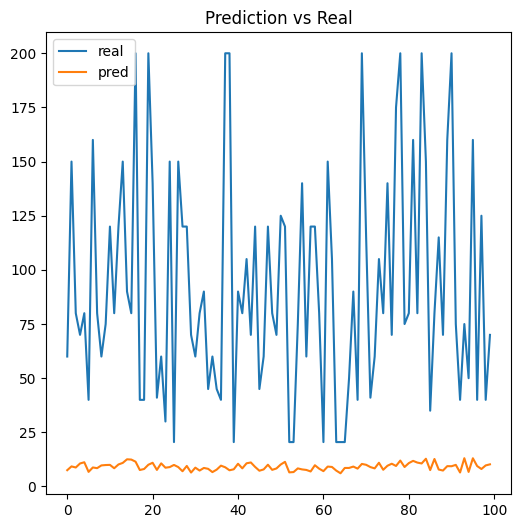

In [46]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[0:100] ,label="real")

plt.plot( pred[0:100] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


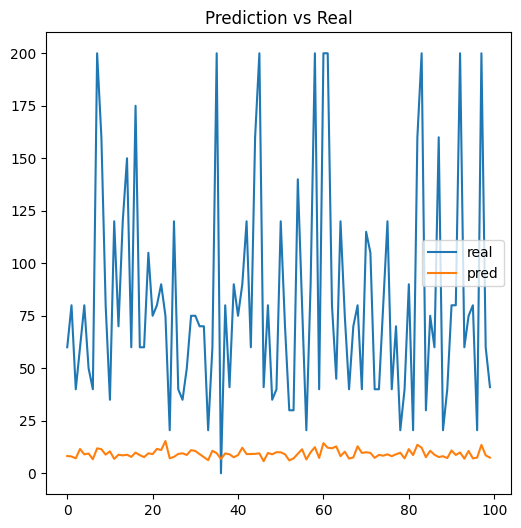

In [47]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[300:400] ,label="real")

plt.plot( pred[300:400] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


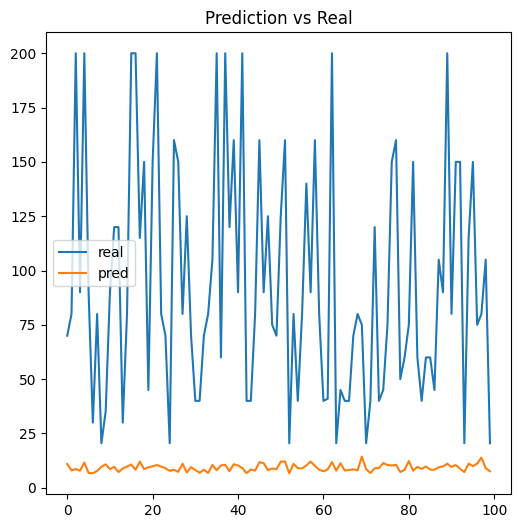

In [48]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[700:800] ,label="real")

plt.plot( pred[700:800] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()
